# XGBoost: compare feature sets (Master lagged) → **C5** or **log(C5)**

- **Features (Part 1 — master lagged):** resolved automatically — prefers **`Moving_Average_Features_Lagged__from_*.xlsx`** (Feature Engineering naming), then **`Master_Data_AVG_version_update_Lagged.xlsx`**. Override with **`XGBOOST_MASTER_LAGGED_XLSX`**.
- **Target:** C5 master — **`Master_Data_Base_version_Brownian_by_frequency.xlsx`** preferred, then **`Master_Data_AVG_version_update.xlsx`**. Override **`XGBOOST_MASTER_XLSX`**.
- **Part 2 deseason side:** **`Transformed_Deseason_Residual_Browian.xlsx`** preferred, then **`Transformed_Deseason_Residuals_Lagged.xlsx`**. Override **`XGBOOST_FEATURES_XLSX`** (same env as `XGBoost_log_C5_Prediction.ipynb`).
- **Dropped columns:** all numeric except **`C5_lag_39`**, **`C5_ma_63`**, and any `*_pred` / `XGBoost_pred` leakage columns (Part 1).
- Set **`USE_LOG_TARGET`** in the config cell: **`True`** → **log(C5)** with **`log_C5_*`** AR features; **`False`** → **C5** level with **`C5_*`** AR features (default).
- **Process:** walk-forward / time CV + `SelectKBest`, variance filter, `ar_plus_kbest`, `xgb_importance` — same **feature-set menu** as `XGBoost_log_C5_Prediction.ipynb`.
- **Output:** filenames include **`__from_<master-lagged-stem>__master_<master-stem>`** (Part 1) and **`...__feat_<deseason-stem>`** (Part 2) so runs are distinguishable — first sheet **`model_features_by_selection`** matches **`XGBoost_model_features_by_selection.xlsx`**: `feature_index` + columns `{method} | n=… | Test_R2=…` with feature names below (grey bold header row). Other sheets: `run_meta`, `comparison`, `best_params_by_set`, long `features_by_set`, `feature_importance`.
- **Plots:** horizontal bar charts of top-20 importances for **each** tuned model.

## Parts
- **Part 1:** resolved master-lagged workbook only → tagged **`XGBoost_Master_Lagged_C5_feature_sets_results__from_*.xlsx`**.
- **Part 2:** merged master-lagged + deseason workbook (prefixed **`mav_`** / **`ds_`**) → tagged **`XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results__from_*.xlsx`**.


In [1]:
# %pip install -q xgboost scikit-learn openpyxl pandas

In [2]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

def _first_path(cands, base: Path):
    for c in cands:
        if not c:
            continue
        p = Path(c)
        if p.is_file():
            return p.resolve()
        q = base / c
        if q.is_file():
            return q.resolve()
    return None


BASE_DIR = Path.cwd()
_markers = (
    "Transformed_Deseason_Residual_Browian.xlsx",
    "Transformed_Deseason_Residuals_Lagged.xlsx",
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
    "Master_Data_AVG_version_update_Lagged.xlsx",
    "Master_Data_AVG_version_update.xlsx",
)
if not any((BASE_DIR / m).is_file() for m in _markers):
    BASE_DIR = Path.home() / "Downloads" / "Project 005 Data"

_master_lagged_cands = [
    os.environ.get("XGBOOST_MASTER_LAGGED_XLSX"),
    "Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update.xlsx",
    "Master_Data_AVG_version_update_Lagged.xlsx",
]
_master_cands = [
    os.environ.get("XGBOOST_MASTER_XLSX"),
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
    "Master_Data_AVG_version_update.xlsx",
]
_deseason_cands = [
    os.environ.get("XGBOOST_FEATURES_XLSX"),
    "Transformed_Deseason_Residual_Browian.xlsx",
    "Transformed_Deseason_Residuals_Lagged.xlsx",
]

LAGGED_FILE = _first_path(_master_lagged_cands, BASE_DIR)
MASTER_FILE = _first_path(_master_cands, BASE_DIR)
DESEASON_LAGGED_FILE = _first_path(_deseason_cands, BASE_DIR)

if LAGGED_FILE is None:
    raise FileNotFoundError("No master-lagged workbook found. Tried: " + ", ".join(str(x) for x in _master_lagged_cands if x))
if MASTER_FILE is None:
    raise FileNotFoundError("No C5 master workbook found. Tried: " + ", ".join(str(x) for x in _master_cands if x))

LAGGED_STEM = LAGGED_FILE.stem
MASTER_STEM = MASTER_FILE.stem
if DESEASON_LAGGED_FILE is None:
    DESEASON_STEM = "missing_deseason"
    print(
        "WARNING: No deseason/residual workbook (Part 2 needs one). Tried:",
        ", ".join(str(x) for x in _deseason_cands if x),
    )
else:
    DESEASON_STEM = DESEASON_LAGGED_FILE.stem
OUTPUT_RUN_TAG_P1 = f"{LAGGED_STEM}__master_{MASTER_STEM}"
OUTPUT_RUN_TAG_P2 = f"{LAGGED_STEM}__master_{MASTER_STEM}__feat_{DESEASON_STEM}"

OUT_XLSX = (
    BASE_DIR
    / f"XGBoost_Master_Lagged_C5_feature_sets_results__from_{OUTPUT_RUN_TAG_P1}.xlsx"
)
OUT_XLSX_PART2 = (
    BASE_DIR
    / f"XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results__from_{OUTPUT_RUN_TAG_P2}.xlsx"
)

EXCLUDE_EXACT = {"C5_lag_39", "C5_ma_63"}
MODEL_GENERATED_PATTERNS = ("XGBoost_pred", "_pred")

print("BASE_DIR:", BASE_DIR)
print("LAGGED_FILE:", LAGGED_FILE)
print("MASTER_FILE:", MASTER_FILE)
print("DESEASON_LAGGED_FILE:", DESEASON_LAGGED_FILE)
print("OUT_XLSX (Part 1):", OUT_XLSX.name)
print("OUT_XLSX_PART2:", OUT_XLSX_PART2.name)


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


BASE_DIR: /Users/andyyang/Downloads/Project 005 Data
LAGGED_FILE: /Users/andyyang/Downloads/Project 005 Data/Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update.xlsx
MASTER_FILE: /Users/andyyang/Downloads/Project 005 Data/Master_Data_Base_version_Brownian_by_frequency.xlsx
DESEASON_LAGGED_FILE: /Users/andyyang/Downloads/Project 005 Data/Transformed_Deseason_Residual_Browian.xlsx
OUT_XLSX (Part 1): XGBoost_Master_Lagged_C5_feature_sets_results__from_Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update__master_Master_Data_Base_version_Brownian_by_frequency.xlsx
OUT_XLSX_PART2: XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results__from_Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update__master_Master_Data_Base_version_Brownian_by_frequency__feat_Transformed_Deseason_Residual_Browian.xlsx


In [3]:
USE_OUT_OF_SAMPLE = True

# Target scale — same pattern as XGBoost_log_C5_Prediction.ipynb
USE_LOG_TARGET = False
PRED_COL = "log_C5_XGBoost_pred" if USE_LOG_TARGET else "C5_XGBoost_pred"
AR_COLS = (
    ["log_C5_lag1", "log_C5_lag2", "log_C5_lag5", "log_C5_lag10", "log_C5_lag20", "log_C5_rolling5", "log_C5_rolling20"]
    if USE_LOG_TARGET
    else ["C5_lag1", "C5_lag2", "C5_lag5", "C5_lag10", "C5_lag20", "C5_rolling5", "C5_rolling20"]
)

# Calendar split (adjust if your master ends earlier)
train_end = "2024-12-31"
test_start = "2025-01-01"
test_end = "2025-03-31"


## Part 1: Master lagged only

Uses the resolved **master-lagged** workbook from the path cell (next).


In [4]:
if not LAGGED_FILE.is_file():
    raise FileNotFoundError(
        f"Missing {LAGGED_FILE.name}. Place it in BASE_DIR or adjust LAGGED_FILE."
    )

features_df = pd.read_excel(LAGGED_FILE)
features_df.columns = pd.Index(str(c) for c in features_df.columns)
date_col = "Date" if "Date" in features_df.columns else features_df.columns[0]
features_df[date_col] = pd.to_datetime(features_df[date_col], errors="coerce")
features_df = features_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

exc_pred = [c for c in features_df.columns if any(p in str(c) for p in MODEL_GENERATED_PATTERNS)]
exc_named = [c for c in features_df.columns if str(c) in EXCLUDE_EXACT]
drop_cols = list(dict.fromkeys(exc_pred + exc_named))
if drop_cols:
    features_df = features_df.drop(columns=drop_cols, errors="ignore")
    print("Dropped columns:", len(drop_cols), "(pred patterns + C5_lag_39 / C5_ma_63)")

numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
features_df = features_df[numeric_cols].copy()
print(f"Lagged features (numeric): {features_df.shape[0]} rows × {features_df.shape[1]} cols")

Lagged features (numeric): 5494 rows × 358 cols


In [5]:
if not MASTER_FILE.is_file():
    raise FileNotFoundError(MASTER_FILE)

master_df = pd.read_excel(MASTER_FILE)
mdate = "Date" if "Date" in master_df.columns else master_df.columns[0]
master_df[mdate] = pd.to_datetime(master_df[mdate], errors="coerce")
master_df = master_df.set_index(mdate).sort_index()

c5_raw = master_df["C5"].astype(float)
if USE_LOG_TARGET:
    target_series = np.log(c5_raw.replace(0, np.nan)).dropna()
    _tgt_desc = "log(C5)"
else:
    target_series = c5_raw.replace(0, np.nan).dropna()
    _tgt_desc = "C5 (level)"

target_series = target_series.loc[(target_series.index >= "2015-01-01") & (target_series.index <= "2025-12-31")]
print(f"Target {_tgt_desc}: {len(target_series)} rows | {target_series.index.min().date()} → {target_series.index.max().date()}")
# Alias for snippets / older cells that still use `c5` (must match `target_series` for alignment).
c5 = target_series
target_series.head()


Target C5 (level): 2746 rows | 2015-01-02 → 2025-12-24


Date
2015-01-02    4.994
2015-01-05    4.900
2015-01-06    4.741
2015-01-07    4.580
2015-01-08    4.277
Name: C5, dtype: float64

In [6]:
def align_features_and_split(features_df, target_series):
    """Align covariates to target, add AR cols, train/test split."""
    common_idx = features_df.index.intersection(target_series.index)
    X = features_df.loc[common_idx].copy()
    X.columns = pd.Index(str(c) for c in X.columns)
    y = target_series.loc[common_idx].copy()
    valid = y.notna()
    X = X.loc[valid]
    y = y.loc[valid]
    X = X.fillna(0)
    X = X.drop(columns=[c for c in AR_COLS if c in X.columns], errors="ignore")
    ar_features = pd.DataFrame(
        {
            AR_COLS[0]: y.shift(1),
            AR_COLS[1]: y.shift(2),
            AR_COLS[2]: y.shift(5),
            AR_COLS[3]: y.shift(10),
            AR_COLS[4]: y.shift(20),
            AR_COLS[5]: y.rolling(5, min_periods=1).mean().shift(1),
            AR_COLS[6]: y.rolling(20, min_periods=1).mean().shift(1),
        },
        index=X.index,
    )
    X = pd.concat([X, ar_features], axis=1)
    ar_valid = X[ar_features.columns].notna().all(axis=1)
    X = X.loc[ar_valid]
    y = y.loc[ar_valid]
    X = X.fillna(0)
    print(f"Aligned X {X.shape}, y {y.shape}")
    X = X.sort_index()
    y = y.sort_index()
    if USE_OUT_OF_SAMPLE:
        train_mask = (X.index >= "2015-01-01") & (X.index <= train_end)
        test_mask = (X.index >= test_start) & (X.index <= test_end)
        X_train, X_test = X.loc[train_mask], X.loc[test_mask]
        y_train, y_test = y.loc[train_mask], y.loc[test_mask]
        if len(X_train) == 0 or len(X_test) == 0:
            raise ValueError("Empty train or test split; check dates vs data.")
        print("Train:", X_train.index.min().date(), "→", X_train.index.max().date(), "|", len(X_train))
        print("Test:", X_test.index.min().date(), "→", X_test.index.max().date(), "|", len(X_test))
    else:
        X_train = X_test = X
        y_train = y_test = y
        print("Full-sample mode (no OOS):", len(X_train), "rows")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = align_features_and_split(features_df, target_series)


Aligned X (2726, 365), y (2726,)
Train: 2015-01-30 → 2024-12-24 | 2476
Test: 2025-01-02 → 2025-03-31 | 63


In [7]:
# `align_features_and_split` in the previous cell builds `X_train`, `X_test`, `y_train`, `y_test`.


In [8]:
def mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-10
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def apply_feature_selection(method_name, X_tr, y_tr, X_te):
    if method_name == "none":
        cols = list(X_tr.columns)
        return X_tr.copy(), X_te.copy(), {"method": method_name, "selected_cols": cols}

    if method_name == "variance_corr":
        vt = VarianceThreshold(threshold=1e-8)
        X_tr_v = pd.DataFrame(
            vt.fit_transform(X_tr), index=X_tr.index, columns=X_tr.columns[vt.get_support()]
        )
        X_te_v = pd.DataFrame(vt.transform(X_te), index=X_te.index, columns=X_tr_v.columns)
        corr = X_tr_v.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop_cols = [c for c in upper.columns if any(upper[c] > 0.98)]
        X_tr_f = X_tr_v.drop(columns=drop_cols, errors="ignore")
        X_te_f = X_te_v.drop(columns=drop_cols, errors="ignore")
        return X_tr_f, X_te_f, {"method": method_name, "selected_cols": list(X_tr_f.columns)}

    if method_name.startswith("kbest_"):
        k_map = {"kbest_f": 120, "kbest_40": 40, "kbest_60": 60, "kbest_80": 80}
        k = min(k_map.get(method_name, 120), X_tr.shape[1])
        skb = SelectKBest(score_func=f_regression, k=k)
        sup = skb.fit(X_tr, y_tr).get_support()
        cols = X_tr.columns[sup]
        X_tr_k = pd.DataFrame(skb.transform(X_tr), index=X_tr.index, columns=cols)
        X_te_k = pd.DataFrame(skb.transform(X_te), index=X_te.index, columns=cols)
        return X_tr_k, X_te_k, {"method": method_name, "selected_cols": list(cols)}

    if method_name.startswith("ar_plus_kbest_"):
        k = int(method_name.split("_")[-1])
        ar_present = [c for c in AR_COLS if c in X_tr.columns]
        non_ar = [c for c in X_tr.columns if c not in AR_COLS]
        if not non_ar:
            return X_tr.copy(), X_te.copy(), {"method": method_name, "selected_cols": list(X_tr.columns)}
        k_sel = min(k, len(non_ar))
        skb = SelectKBest(score_func=f_regression, k=k_sel)
        X_na_tr, X_na_te = X_tr[non_ar], X_te[non_ar]
        skb.fit(X_na_tr, y_tr)
        csel = X_na_tr.columns[skb.get_support()]
        X_tr_sel = pd.DataFrame(skb.transform(X_na_tr), index=X_tr.index, columns=csel)
        X_te_sel = pd.DataFrame(skb.transform(X_na_te), index=X_te.index, columns=csel)
        X_tr_out = pd.concat([X_tr[ar_present], X_tr_sel], axis=1)
        X_te_out = pd.concat([X_te[ar_present], X_te_sel], axis=1)
        return X_tr_out, X_te_out, {"method": method_name, "selected_cols": list(X_tr_out.columns)}

    if method_name == "xgb_importance":
        temp = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            min_child_weight=15,
            subsample=0.7,
            colsample_bytree=0.6,
            gamma=0.3,
            reg_alpha=0.1,
            reg_lambda=5.0,
            random_state=42,
            n_jobs=1,
        )
        temp.fit(X_tr, y_tr)
        imp = pd.Series(temp.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
        sel = list(imp.head(min(80, len(imp))).index)
        return X_tr[sel].copy(), X_te[sel].copy(), {"method": method_name, "selected_cols": sel}

    raise ValueError(method_name)


param_grid = {
    "n_estimators": [300, 600],
    "learning_rate": [0.01, 0.03],
    "max_depth": [1, 2],
    "min_child_weight": [15, 25],
    "subsample": [0.6],
    "colsample_bytree": [0.5],
    "gamma": [0.3],
    "reg_alpha": [0.1],
    "reg_lambda": [5.0, 10.0],
}

fs_methods = [
    "kbest_40",
    "kbest_60",
    "kbest_80",
    "ar_plus_kbest_60",
    "variance_corr",
    "xgb_importance",
]


def run_xgb_comparison(X_train, y_train, X_test, y_test, part_label=""):
    results = []
    model_store = {}
    val_start = (pd.Timestamp(train_end) - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
    wf_train = X_train.index < val_start
    wf_val = (X_train.index >= val_start) & (X_train.index <= train_end)
    tr_i, va_i = np.where(wf_train)[0], np.where(wf_val)[0]
    if len(tr_i) > 0 and len(va_i) > 0:
        cv_splits = [(tr_i, va_i)]
        print(f"Walk-forward CV: train < {val_start}, val {val_start} … {train_end}")
    else:
        cv_splits = TimeSeriesSplit(n_splits=4)
        print("TimeSeriesSplit(4)")

    for fs_name in fs_methods:
        X_tr_fs, X_te_fs, fs_meta = apply_feature_selection(fs_name, X_train, y_train, X_test)
        base = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=1)
        grid = GridSearchCV(
            base,
            param_grid,
            scoring="neg_mean_squared_error",
            cv=cv_splits,
            n_jobs=1,
            verbose=0,
        )
        grid.fit(X_tr_fs, y_train)
        best = grid.best_estimator_
        y_ptr = best.predict(X_tr_fs)
        y_pte = best.predict(X_te_fs)

        if USE_OUT_OF_SAMPLE:
            test_r2 = r2_score(y_test, y_pte)
            test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pte)))
            test_mae = mean_absolute_error(y_test, y_pte)
            test_mape = mape(y_test.values, y_pte)
        else:
            test_r2 = test_rmse = test_mae = test_mape = np.nan

        results.append(
            {
                "FeatureSet": fs_name,
                "N_Features": X_tr_fs.shape[1],
                "Best_CV_RMSE": float(np.sqrt(-grid.best_score_)),
                "Train_R2": r2_score(y_train, y_ptr),
                "Test_R2": test_r2,
                "Train_RMSE": float(np.sqrt(mean_squared_error(y_train, y_ptr))),
                "Test_RMSE": test_rmse,
                "Train_MAE": mean_absolute_error(y_train, y_ptr),
                "Test_MAE": test_mae,
                "Train_MAPE_pct": mape(y_train.values, y_ptr),
                "Test_MAPE_pct": test_mape,
                "Best_Params_json": json.dumps(grid.best_params_),
            }
        )
        model_store[fs_name] = {"model": best, "meta": fs_meta, "params": grid.best_params_}

    sort_col = "Best_CV_RMSE" if not USE_OUT_OF_SAMPLE else "Test_RMSE"
    results_df = pd.DataFrame(results).sort_values(sort_col).reset_index(drop=True)
    tag = f"[{part_label}] " if part_label else ""
    print(f"\n{tag}Comparison (sorted by {sort_col})\n")
    print(results_df.drop(columns=["Best_Params_json"], errors="ignore").to_string(index=False))
    best_fs = results_df.loc[0, "FeatureSet"]
    print(f"\n{tag}Best feature set (by {sort_col}):", best_fs)
    return results_df, model_store, best_fs, sort_col


results_df, model_store, best_fs, sort_col = run_xgb_comparison(
    X_train, y_train, X_test, y_test, part_label="Part 1"
)


Walk-forward CV: train < 2024-09-30, val 2024-09-30 … 2024-12-31


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)



[Part 1] Comparison (sorted by Test_RMSE)

      FeatureSet  N_Features  Best_CV_RMSE  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_MAPE_pct  Test_MAPE_pct
  xgb_importance          80      0.175730  0.997245 0.990942    0.153307   0.165079   0.108171  0.121169        1.408528       1.592044
ar_plus_kbest_60          67      0.372155  0.987514 0.949987    0.326391   0.387888   0.231164  0.278513        2.927781       3.536421
        kbest_40          40      0.378769  0.986563 0.949118    0.338590   0.391244   0.241147  0.280398        3.048717       3.539574
        kbest_60          60      0.364242  0.986682 0.947751    0.337080   0.396466   0.239744  0.288296        3.019065       3.693103
        kbest_80          80      0.370146  0.975865 0.946882    0.453778   0.399750   0.294266  0.291065        3.785686       3.711984
   variance_corr         203      0.371526  0.976703 0.910421    0.445824   0.519122   0.313638  0.421234        4.184291       5.8117

In [9]:
def export_xgb_results(out_path: Path, part_tag: str, lagged_description: str):
    rows_long = []
    for fs_name in results_df["FeatureSet"]:
        cols = model_store[fs_name]["meta"]["selected_cols"]
        for rank, fname in enumerate(cols, 1):
            rows_long.append({"FeatureSet": fs_name, "Rank": rank, "Feature": fname})
    features_long = pd.DataFrame(rows_long)

    feat_by_model = {}
    for _, row in results_df.iterrows():
        fs = row["FeatureSet"]
        names = list(model_store[fs]["meta"]["selected_cols"])
        n_feat = int(row["N_Features"])
        tr2 = row["Test_R2"]
        r2_str = f"{float(tr2):.6f}" if pd.notna(tr2) else "NA"
        col_header = f"{fs} | n={n_feat} | Test_R2={r2_str}"
        feat_by_model[col_header] = names

    if feat_by_model:
        max_rows = max(len(v) for v in feat_by_model.values())
        export_dict = {"feature_index": list(range(1, max_rows + 1))}
        for hdr, names in feat_by_model.items():
            export_dict[hdr] = names + [None] * (max_rows - len(names))
        features_wide = pd.DataFrame(export_dict)
    else:
        features_wide = pd.DataFrame({"feature_index": []})

    params_rows = [{"FeatureSet": k, "Best_Params_json": json.dumps(v["params"])} for k, v in model_store.items()]
    params_df = pd.DataFrame(params_rows)

    imp_rows = []
    for fs_name in results_df["FeatureSet"]:
        model = model_store[fs_name]["model"]
        cols = model_store[fs_name]["meta"]["selected_cols"]
        imps = model.feature_importances_
        order = np.argsort(-imps)
        for rank, j in enumerate(order, start=1):
            imp_rows.append(
                {
                    "FeatureSet": fs_name,
                    "Rank": rank,
                    "Feature": cols[j],
                    "Importance": float(imps[j]),
                }
            )
    importance_long = pd.DataFrame(imp_rows)

    meta = pd.DataFrame(
        [
            {
                "PART": part_tag,
                "LAGGED_SOURCES": lagged_description,
                "MASTER_FILE": str(MASTER_FILE),
                "USE_LOG_TARGET": USE_LOG_TARGET,
                "PRED_COL": PRED_COL,
                "TARGET": ("log(C5)" if USE_LOG_TARGET else "C5_level"),
                "EXCLUDED_COLUMNS": ", ".join(sorted(EXCLUDE_EXACT)),
                "TRAIN_END": train_end,
                "TEST_WINDOW": f"{test_start} … {test_end}",
                "SORT_METRIC": sort_col,
                "BEST_FEATURE_SET": best_fs,
            }
        ]
    )

    with pd.ExcelWriter(out_path, engine="openpyxl") as w:
        features_wide.to_excel(w, sheet_name="model_features_by_selection", index=False)
        meta.to_excel(w, sheet_name="run_meta", index=False)
        results_df.to_excel(w, sheet_name="comparison", index=False)
        params_df.to_excel(w, sheet_name="best_params_by_set", index=False)
        features_long.to_excel(w, sheet_name="features_by_set", index=False)
        importance_long.to_excel(w, sheet_name="feature_importance", index=False)

    from openpyxl import load_workbook
    from openpyxl.styles import Alignment, Font, PatternFill

    wb = load_workbook(out_path)
    ws = wb["model_features_by_selection"]
    hdr_fill = PatternFill(fill_type="solid", fgColor="D9D9D9")
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.fill = hdr_fill
        cell.alignment = Alignment(horizontal="left", vertical="center")
    for col in ws.iter_cols(min_row=1, max_row=min(ws.max_row, 500), min_col=1, max_col=ws.max_column):
        letter = col[0].column_letter
        wch = max((len(str(c.value)) if c.value is not None else 0) for c in col) + 2
        ws.column_dimensions[letter].width = min(max(wch, 12), 90)
    wb.save(out_path)
    print("Saved:", out_path)
    print("  Sheet 'model_features_by_selection' = wide format (like XGBoost_model_features_by_selection.xlsx)")


export_xgb_results(
    OUT_XLSX,
    "Part1_MasterLaggedOnly",
    str(LAGGED_FILE),
)


Saved: /Users/andyyang/Downloads/Project 005 Data/XGBoost_Master_Lagged_C5_feature_sets_results__from_Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update__master_Master_Data_Base_version_Brownian_by_frequency.xlsx
  Sheet 'model_features_by_selection' = wide format (like XGBoost_model_features_by_selection.xlsx)


[Part 1] Top 15 feature importances (best set: xgb_importance ):
                                     Feature  Importance
                                    C5_lag_1    0.266049
                                     C5_lag1    0.163991
                                     C5_ma_1    0.114048
                                     C5_lag2    0.079714
                         hrc_USD/MT_EU_ma_63    0.065155
                           C3 1 Mon FFA_ma_1    0.044048
                                 C5_rolling5    0.042390
              1 Month FFA Route Average_ma_2    0.041542
                          IRONORE_FUT_lag_60    0.033539
             1 Month FFA Route Average_lag_1    0.017276
    Capesize Bulkcarrier Deliveries_No_ma_63    0.013285
   Capesize Bulkcarrier Deliveries_DWT_ma_63    0.013052
                      Galvanized 1.0mm_ma_63    0.011911
              2 Month FFA Route Average_ma_2    0.011057
crude steel Non-key enterprises daily_lag_44    0.009589


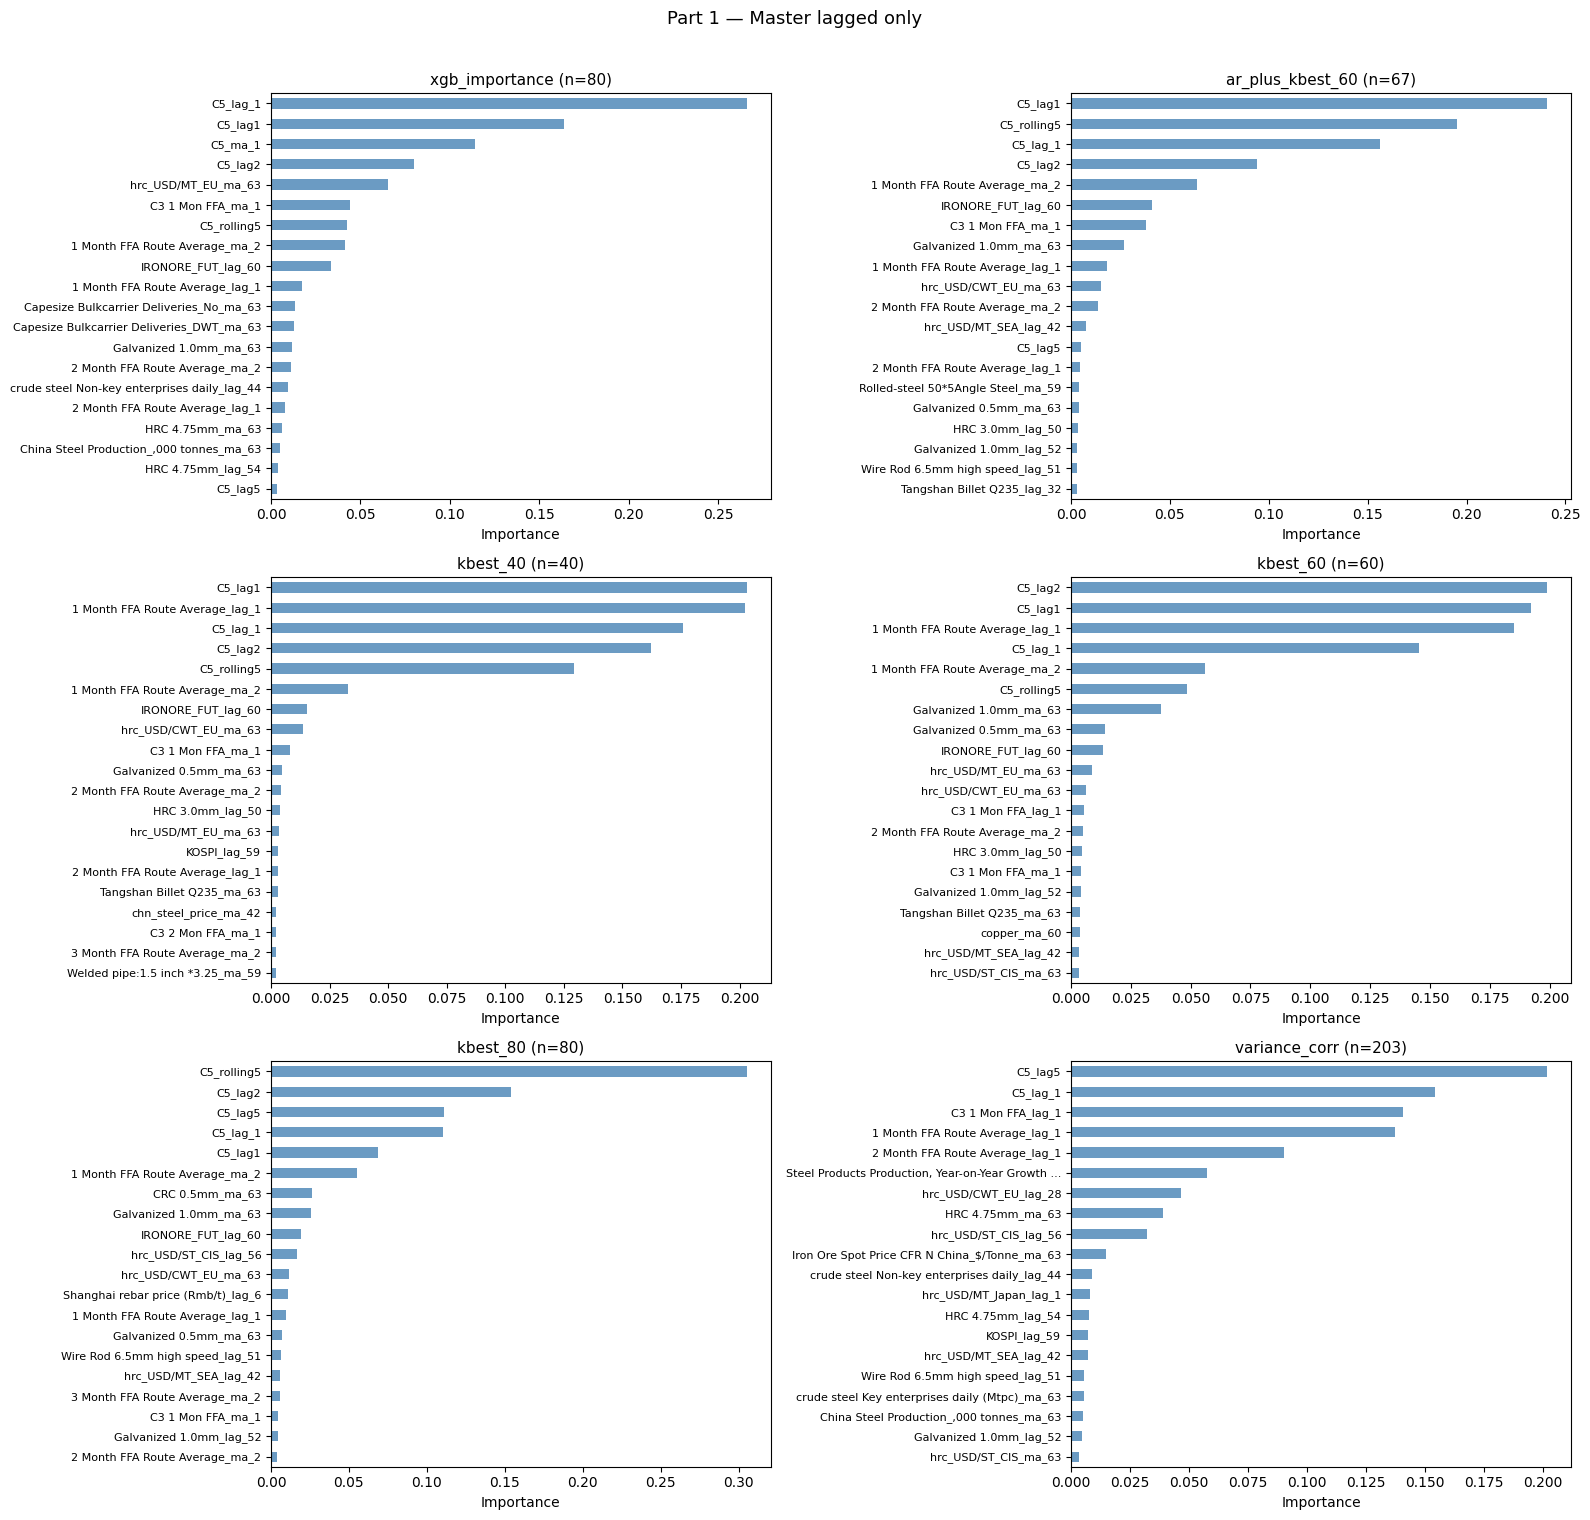

In [10]:
# Part 1 — feature importances (stdout + barh grid)
_best = model_store[best_fs]["model"]
_best_cols = model_store[best_fs]["meta"]["selected_cols"]
best_imp = (
    pd.DataFrame({"Feature": _best_cols, "Importance": _best.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
print("[Part 1] Top 15 feature importances (best set:", best_fs, "):")
print(best_imp.head(15).to_string(index=False))

N_TOP = 20
n_models = len(model_store)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.atleast_2d(axes)
fig.suptitle("Part 1 — Master lagged only", fontsize=13, y=1.01)
for idx, fs_name in enumerate(results_df["FeatureSet"].tolist()):
    row, col_ = idx // n_cols, idx % n_cols
    ax = axes[row, col_]
    model = model_store[fs_name]["model"]
    cols = model_store[fs_name]["meta"]["selected_cols"]
    imp = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=True)
    imp_top = imp.tail(N_TOP)
    imp_top.index = [s[:47] + "..." if len(str(s)) > 50 else str(s) for s in imp_top.index]
    imp_top.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"{fs_name} (n={len(cols)})", fontsize=11)
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=8)
for idx in range(n_models, n_rows * n_cols):
    row, col_ = idx // n_cols, idx % n_cols
    axes[row, col_].set_visible(False)
plt.tight_layout()
plt.show()


## Part 2: Master lagged + Deseason residuals/lagged (merged)

Loads **both** resolved workbooks, prefixes columns **`mav_`** (master lagged) and **`ds_`** (deseason) to avoid name clashes, then repeats the same XGBoost feature-set comparison. Output filename is tagged in the path cell (**`OUT_XLSX_PART2`**).


Part 2 merged features_df: 5494 rows × 712 cols
Aligned X (2726, 719), y (2726,)
Train: 2015-01-30 → 2024-12-24 | 2476
Test: 2025-01-02 → 2025-03-31 | 63
Walk-forward CV: train < 2024-09-30, val 2024-09-30 … 2024-12-31


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:380: RuntimeWarning: invalid value encountered in sqrt
  X_norms = np.sqrt(row_norms(X.T, squared=True) - n_samples * X_means**2)



[Part 2] Comparison (sorted by Test_RMSE)

      FeatureSet  N_Features  Best_CV_RMSE  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_MAPE_pct  Test_MAPE_pct
  xgb_importance          80      0.170934  0.996974 0.988370    0.160676   0.187052   0.113567  0.141131        1.468265       1.872935
ar_plus_kbest_60          67      0.372155  0.987514 0.949987    0.326391   0.387888   0.231164  0.278513        2.927781       3.536421
        kbest_40          40      0.378769  0.986563 0.949118    0.338590   0.391244   0.241147  0.280398        3.048717       3.539574
        kbest_60          60      0.364242  0.986682 0.947751    0.337080   0.396466   0.239744  0.288296        3.019065       3.693103
        kbest_80          80      0.370146  0.975865 0.946882    0.453778   0.399750   0.294266  0.291065        3.785686       3.711984
   variance_corr         517      0.381011  0.987840 0.906673    0.322092   0.529872   0.236806  0.426741        3.065504       5.6358

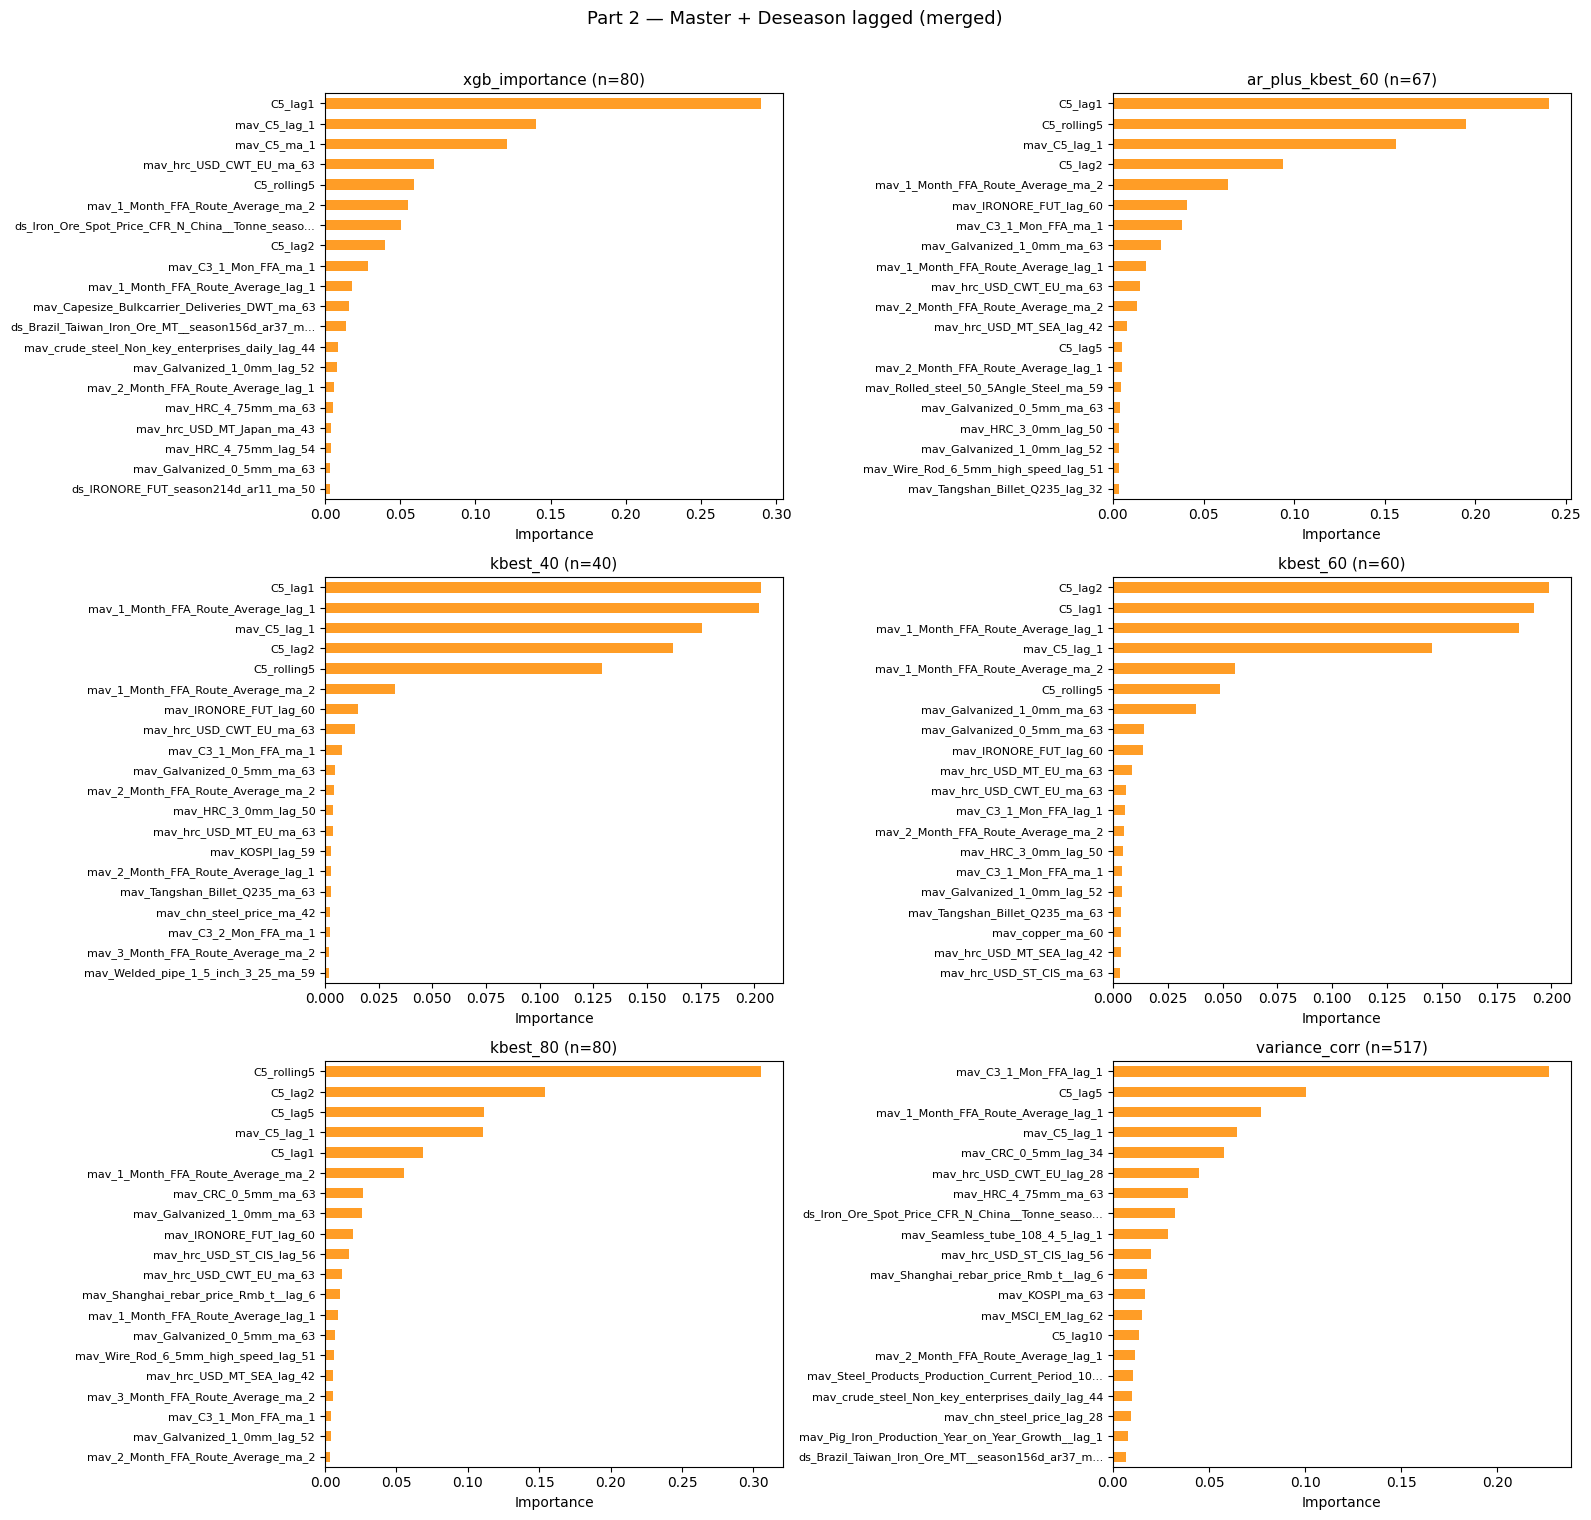

In [11]:
import re as _re_m

def _prep_lagged_numeric(path: Path, col_prefix: str, exclude_exact=None):
    if not path.is_file():
        raise FileNotFoundError(path)
    df = pd.read_excel(path)
    df.columns = pd.Index(str(c) for c in df.columns)
    dcol = "Date" if "Date" in df.columns else df.columns[0]
    df[dcol] = pd.to_datetime(df[dcol], errors="coerce")
    df = df.dropna(subset=[dcol]).set_index(dcol).sort_index()
    df.index = pd.to_datetime(df.index, errors="coerce").normalize()
    drop_pred = [c for c in df.columns if any(p in str(c) for p in MODEL_GENERATED_PATTERNS)]
    if drop_pred:
        df = df.drop(columns=drop_pred, errors="ignore")
    if exclude_exact:
        ex = [c for c in df.columns if str(c) in exclude_exact]
        if ex:
            df = df.drop(columns=ex, errors="ignore")
    num = df.select_dtypes(include=[np.number]).copy()
    seen = set()
    rename = {}
    for j, src in enumerate(num.columns):
        base = col_prefix + (_re_m.sub(r"[^\w]+", "_", str(src)).strip("_")[:100] or "feat")
        nm = base
        k = 0
        while nm in seen:
            k += 1
            nm = f"{base}_{j}_{k}"
        seen.add(nm)
        rename[src] = nm
    out = num.rename(columns=rename)
    return out


if DESEASON_LAGGED_FILE is None or not DESEASON_LAGGED_FILE.is_file():
    raise FileNotFoundError(
        "Part 2 requires a deseason/residual workbook. Set XGBOOST_FEATURES_XLSX or add "
        "Transformed_Deseason_Residual_Browian.xlsx / Transformed_Deseason_Residuals_Lagged.xlsx under BASE_DIR."
    )

_mav = _prep_lagged_numeric(LAGGED_FILE, "mav_", EXCLUDE_EXACT)
_ds = _prep_lagged_numeric(DESEASON_LAGGED_FILE, "ds_", None)
_all_idx = _mav.index.union(_ds.index).sort_values()
features_df = pd.concat(
    [_mav.reindex(_all_idx).sort_index().ffill(), _ds.reindex(_all_idx).sort_index().ffill()],
    axis=1,
)
print("Part 2 merged features_df:", features_df.shape[0], "rows ×", features_df.shape[1], "cols")

X_train, X_test, y_train, y_test = align_features_and_split(features_df, target_series)
results_df, model_store, best_fs, sort_col = run_xgb_comparison(
    X_train, y_train, X_test, y_test, part_label="Part 2"
)

export_xgb_results(
    OUT_XLSX_PART2,
    "Part2_MasterPlusDeseasonLagged",
    f"{LAGGED_FILE.name} + {DESEASON_LAGGED_FILE.name} (mav_ / ds_ prefixes)",
)

_best = model_store[best_fs]["model"]
_best_cols = model_store[best_fs]["meta"]["selected_cols"]
best_imp = (
    pd.DataFrame({"Feature": _best_cols, "Importance": _best.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
print("[Part 2] Top 15 feature importances (best set:", best_fs, "):")
print(best_imp.head(15).to_string(index=False))

N_TOP = 20
n_models = len(model_store)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.atleast_2d(axes)
fig.suptitle("Part 2 — Master + Deseason lagged (merged)", fontsize=13, y=1.01)
for idx, fs_name in enumerate(results_df["FeatureSet"].tolist()):
    row, col_ = idx // n_cols, idx % n_cols
    ax = axes[row, col_]
    model = model_store[fs_name]["model"]
    cols = model_store[fs_name]["meta"]["selected_cols"]
    imp = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=True)
    imp_top = imp.tail(N_TOP)
    imp_top.index = [s[:47] + "..." if len(str(s)) > 50 else str(s) for s in imp_top.index]
    imp_top.plot(kind="barh", ax=ax, color="darkorange", alpha=0.85)
    ax.set_title(f"{fs_name} (n={len(cols)})", fontsize=11)
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=8)
for idx in range(n_models, n_rows * n_cols):
    row, col_ = idx // n_cols, idx % n_cols
    axes[row, col_].set_visible(False)
plt.tight_layout()
plt.show()
